In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier, XGBRegressor
from sklearn.impute import SimpleImputer

In [3]:
# Load dataset
df = pd.read_csv("../data/merged_final_transformed.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (6646, 41)


,year,StateAbbr,County name,CountyFIPS,BPHIGH,CASTHMA,COPD,MHLTH,PHLTH,SLEEP,...,median_age,pct_bachelors_plus,pct_graduate_degree,pct_less_than_hs,pct_white,pct_black,pct_asian,pct_hispanic,median_household_income,climate_type_short
0,2013,AK,ANCHORAGE MUNICIPALITY,2020,28.691667,NaN,NaN,NaN,NaN,NaN,...,32.8,11.7,92.5,23.2,0.1,7.9,7.8,92.0,77454,ET
1,2013,AL,JEFFERSON COUNTY,1073,41.893750,NaN,NaN,NaN,NaN,NaN,...,37.2,11.6,87.4,26.6,0.1,0.8,0.8,96.2,45429,Cfa
2,2013,AL,MADISON COUNTY,1089,37.654348,NaN,NaN,NaN,NaN,NaN,...,37.4,14.5,90.0,21.4,0.1,2.3,2.2,95.4,58434,Cfa
3,2013,AL,MOBILE COUNTY,1097,44.833333,NaN,NaN,NaN,NaN,NaN,...,36.7,7.0,83.9,33.0,0.0,1.4,1.4,97.5,43028,Cfa
4,2013,AL,MONTGOMERY COUNTY,1101,39.792727,NaN,NaN,NaN,NaN,NaN,...,34.8,12.0,85.6,26.2,0.1,1.3,1.1,96.5,44790,Cfa


# Preparing the data with one hat encoding categorical 

In [4]:
# Separate feature types — keep as lists for ColumnTransformer
target = "SLEEP"

df = df.drop(columns=["County name", "CountyFIPS", 'BPHIGH', 'CASTHMA', 'COPD', 'MHLTH', 'PHLTH','STROKE', 'StateAbbr', 'STATION_NAME', 'STATION'])
#Should we drop STATION? STATION_NAME?
categorical_features = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
numerical_features = [c for c in df.select_dtypes(include=['float64', 'int64']).columns
                      if c != target]

# Sleep

SLEEP

In [5]:
# Drop rows where SLEEP is NA
before = len(df)
df = df.dropna(subset=["SLEEP"])
print(f"Dropped {before - len(df)} rows with missing SLEEP values")

Dropped 3451 rows with missing SLEEP values


In [6]:

X = df.drop(target, axis = 1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')


Train: 2556 samples
Test:  639 samples


In [7]:
# Creation of a dictionary to print at the end which we will sort by value 

# We use the R2 score to show the accuracy. We cannot use accuracy_score because we are
# are not using classification algorithms. The closer to 1 the R2 score is the better the
# algorithm is: https://www.geeksforgeeks.org/maths/r-squared/

R2_scores = {}
MSE_scores = {}

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num',
         SimpleImputer(strategy='mean'),
         numerical_features)
    ]
)

# Note: no remainder='passthrough' — all columns are explicitly listed

X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)

print(f"Encoded training matrix shape: {X_train.shape}")

Encoded training matrix shape: (2556, 47)


# Decision Trees

### Tuning tree depth

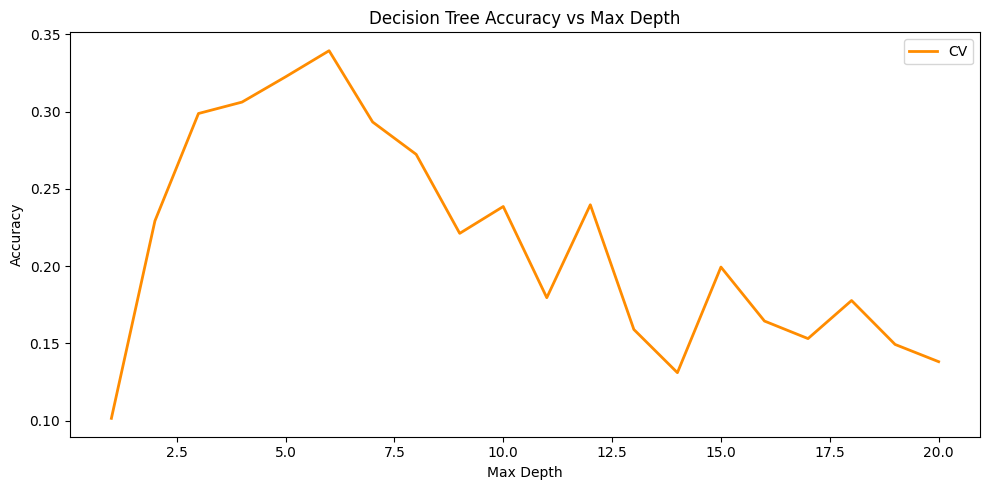

In [17]:
depths = np.arange(1, 21)
dt_train_scores = []
dt_cv_scores = []

for depth in depths:
    dt_tmp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_tmp.fit(X_train, y_train)
    dt_cv_scores.append(np.mean(cross_val_score(dt_tmp, X_train, y_train, cv=10)))

plt.figure(figsize=(10, 5))
plt.plot(depths, dt_cv_scores,    label='CV',    color='darkorange', lw=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.tight_layout()
plt.show()

### Running decision tree with most accurate depth

In [29]:
# most accurate depth
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train, y_train)
dt_reg_pred = dt_reg.predict(X_test)

mse_dt = mean_squared_error(y_test, dt_reg_pred)
r2_dt = r2_score(y_test, dt_reg_pred)
MSE_scores["Decision Tree"] = mse_dt
R2_scores["Decision Tree"] = r2_dt
print(f"Decision Tree Regressor — MSE: {mse_dt:.4f}")

Decision Tree Regressor — MSE: 18.9339


# Random Forest

In [22]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, rf_pred)
print("Random Forest Regressor (default)")
print(f"  Test MSE:      {mse_rf:.4f}")

Random Forest Regressor (default)
  Test MSE:      12.6877


In [24]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
cv_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
cv_rf.fit(X_train, y_train)

print("Best CV MSE:", cv_rf.best_score_.round(4))
print("Best parameters:   ", cv_rf.best_params_)

rf_best = cv_rf.best_estimator_
rf_best_pred = rf_best.predict(X_test)

print()
print("Tuned Random Forest")
print(f"  Test MSE:      {mean_squared_error(y_test, rf_best_pred):.4f}")

Best CV MSE: -8.5783
Best parameters:    {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}

Tuned Random Forest
  Test MSE:      12.5393


In [30]:
# running with best parameters above + n_estimators=200 to compare against n_estimators=300
rf_model = RandomForestRegressor(random_state=42, n_estimators=200, max_depth = 20, min_samples_split=2)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)
MSE_scores["Random Forest"] = mse_rf
R2_scores["Random Forest"] = r2_rf
print("Random Forest Regressor (default)")
print(f"  Test MSE:      {mse_rf:.4f}")

Random Forest Regressor (default)
  Test MSE:      12.6462


Test MSE very similar between n_estimators = 200 and n_estimators = 300 so might be more efficient to stick to n_estimators = 200

# XGBoost

In [26]:
param_grid = {
    'max_depth': [5, 7],
    'min_child_weight': [1, 2],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 150],
    'subsample': [0.75, 0.9],
    'colsample_bytree': [0.75, 0.9]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

xgb_optimized = XGBRegressor(**best_params, random_state=42)
xgb_optimized.fit(X_train, y_train)

y_pred_xgb = xgb_optimized.predict(X_test)

print()
print("Tuned XGBoost Regressor")
print(f"  Test MSE:      {mean_squared_error(y_test, y_pred_xgb):.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}

Tuned XGBoost Regressor
  Test MSE:      12.0363


In [ ]:
# redoing the grid search with slightly different parameter values (for max_depth and n_estimators where we have edge cases)

param_grid = {
    'max_depth': [7, 9],
    'min_child_weight': [1, 2],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [150, 200],
    'subsample': [0.75, 0.9],
    'colsample_bytree': [0.75, 0.9]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

xgb_optimized = XGBRegressor(**best_params, random_state=42)
xgb_optimized.fit(X_train, y_train)

y_pred_xgb = xgb_optimized.predict(X_test)

print()
print("Tuned XGBoost Regressor")
print(f"  Test MSE:      {mean_squared_error(y_test, y_pred_xgb):.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.75}

Tuned XGBoost Regressor
  Test MSE:      11.7243


In [28]:
# one last attempt by changing n_estimators with fixed values of other parameters from those identified above

param_grid = {
    'max_depth': [7],
    'min_child_weight': [1],
    'learning_rate': [0.05],
    'n_estimators': [200, 250, 300],
    'subsample': [0.75],
    'colsample_bytree': [0.75]
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best parameters:", best_params)

xgb_optimized = XGBRegressor(**best_params, random_state=42)
xgb_optimized.fit(X_train, y_train)

y_pred_xgb = xgb_optimized.predict(X_test)

print()
print("Tuned XGBoost Regressor")
print(f"  Test MSE:      {mean_squared_error(y_test, y_pred_xgb):.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.75}

Tuned XGBoost Regressor
  Test MSE:      11.7752


In [31]:
# final XGBoost run
xgb_optimized = XGBRegressor(random_state=42, colsample_bytree = 0.75, max_depth = 7, learning_rate = 0.05,
                             min_child_weight = 1, n_estimators = 200, subsample = 0.75)
xgb_optimized.fit(X_train, y_train)

y_pred_xgb = xgb_optimized.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
MSE_scores["XGBoost"] = mse_xgb
R2_scores["XGBoost"] = r2_xgb
print("Tuned XGBoost Regressor")
print(f"  Test MSE:      {mean_squared_error(y_test, y_pred_xgb):.4f}")

Tuned XGBoost Regressor
  Test MSE:      11.7243


Increasing n_estimators beyond 200 doesn't seem to improve overall performance and is likely to make training more inefficient - so might be best to stick with the following parameters:
colsample_bytree = 0.75
learning_rate = 0.05
max_depth = 7
min_child_weight = 1
n_estimators = 200
subsample = 0.75

# Overall metrics

In [32]:
R2_scores

{'Decision Tree': 0.2519476993797056,
 'Random Forest': 0.5003652522404269,
 'XGBoost': 0.5367890236385366}

In [33]:
sorted_r2 = {key: value for key, 
               value in reversed(sorted(R2_scores.items(), 
                               key=lambda item: item[1]))}

#We sort in reverse order because the best one is the one closest to 1
sorted_r2

{'XGBoost': 0.5367890236385366,
 'Random Forest': 0.5003652522404269,
 'Decision Tree': 0.2519476993797056}

In [34]:
MSE_scores

{'Decision Tree': 18.933874890013506,
 'Random Forest': 12.646203743961275,
 'XGBoost': 11.724285410039435}

In [35]:
sorted_MSE = {key: value for key, 
               value in sorted(MSE_scores.items(), 
                               key=lambda item: item[1])}

# want the one closest to 0 MSE 
sorted_MSE

{'XGBoost': 11.724285410039435,
 'Random Forest': 12.646203743961275,
 'Decision Tree': 18.933874890013506}

XGBoost seems to be the best option among decision tree models (though Random Forest is a close second). For comparison, KRR (best other model) metrics were 0.403 for R2 and 15.1 for MSE, so KRR works better than a simple decision tree but worse than XGBoost and Random Forest.

Resource for manual set up of XGBoost: https://randomrealizations.com/posts/xgboost-from-scratch/